<!-- [md-intro] -->
# Seam fix — before / after

**Verification gate for the A1 trend-estimator fix.** Everything here compares the *shipped
August curves as published* against the *same builds recomputed with the fix*, on both platforms.

## What changed

`reconstruct_matched_daily` rebuilds the first 27 forecast days as `trend × weekday factor`. The
`trend` term used a 7-day centred mean of the **raw** forecast. At the seam that window has no days
to its left, so it collapsed to a forward average of whatever weekdays came next — for the
2026-07-28 Tuesday seam, Tue/Wed/Thu/Fri, **no weekend** — reading ~10% high, and that inflated
figure was then multiplied by the Tuesday factor as though it still needed deseasonalizing.

The fix divides the forecast by **its own** day-of-week profile *before* smoothing. Once the weekly
cycle is gone, a short window is unbiased in weekday terms, so window composition stops mattering.

- **before** = `data-official/2026-06/export_canonical_curves.display_ma` — the frozen copy, exactly
  what produced the published charts. Untouched, so June and July cannot move.
- **after** = `mozaic_daily.seam_ma.display_ma` — the package copy carrying the fix.

## What to check, in order

1. **Dec-15 and every far-horizon value must be identical.** Asserted in `[assert-far-horizon]`.
   This is the whole safety argument: `display_ma` overwrites day 27 onward with the forecast-only
   MA, so no reconstruction change can reach the headline numbers.
2. **The seam step should land on the plain 28-day MA** — the model's own implication, with no
   display-layer distortion either way.
3. **The daily spike should be gone** — `[plot-daily]` shows the rebuilt day-1 value against the
   model's actual forecast, before and after.

## The thing to look at with your own judgement

**The fixed curve does not leave the actuals smoothly — and that is the correct outcome.** Before,
the forecast stepped **+102,595 up** at the seam. After, it steps ~**−108,800 down**, which is what
the model actually says: the plain 28-day MA moves −108,884 that day. The old upward step was a
bug masking a genuine decline.

It reads as a bend rather than a break, because the actuals MA was already falling (−29,967 then
−53,163 on the two days into the seam), so the decline continues and steepens rather than jumping.
Judge whether that is publishable. If you want the curves to *join*, that is a model or a
deliberate display decision — not something to fix in this estimator.


In [1]:
# [setup]
# Loads BOTH implementations side by side. This is the one place in the live tree that imports the
# frozen 2026-06 exporter on purpose -- it is the "before" reference. Per the plan, this import (and
# this notebook's dependence on it) is removed once the fix is signed off; see _archive/_index.md.
import importlib.util
import os
import subprocess
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

os.chdir(subprocess.run(["git", "rev-parse", "--show-toplevel"],
                        capture_output=True, text=True).stdout.strip())
sys.path.insert(0, "src")

# AFTER: the package copy, carrying the A1 fix.
from mozaic_daily.seam_ma import display_ma as display_ma_after      # noqa: E402
from mozaic_daily.seam_ma import reconstruct_matched_daily as recon_after  # noqa: E402
from mozaic_daily.adjustments import load_forecast                   # noqa: E402

# BEFORE: the frozen June implementation, loaded by explicit path so it cannot be confused with the
# package import above and so nothing else in the tree gains a dependency on it.
_FROZEN = "data-official/2026-06/export_canonical_curves.py"
_spec = importlib.util.spec_from_file_location("frozen_export_2026_06", _FROZEN)
frozen = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(frozen)
display_ma_before = frozen.display_ma
recon_before = frozen.reconstruct_matched_daily

WINDOW = 28
SEAM = pd.Timestamp("2026-07-28")
DEC15 = pd.Timestamp("2026-12-15")
PLOTS_DIR = "data-official/2026-08/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# The two published August builds, exactly as the canonical notebook loads them.
BUILDS = {
    "desktop": dict(
        path=("data-official/2026-08/desktop_locked/"
              "mozaic_daily_forecast.2026-07-28.ld-D.adj-lo.parquet"),
        data_source="legacy_desktop", segment='{"os": "ALL"}', app_name="desktop",
        require_state=["l", "o"]),
    "mobile": dict(
        path=("data-official/2026-08/mobile_baseline_2026-07-28/"
              "cps0.035_thresh055_recent13_cpr0.75_ncp25_clip0.6_sps0.1/"
              "mozaic_daily_forecast.2026-07-28.gm-D.adj-m.parquet"),
        data_source="glean_mobile", segment="{}", app_name="ALL MOBILE",
        require_state=["m"]),
}

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})


def millions(x, _pos=None):
    """Two decimals so adjacent ticks on a narrow range stay distinguishable."""
    return f"{x / 1e6:.2f}M"


def load_world_daily(spec):
    """World (ALL-country) daily DAU for one build, as a date-indexed Series."""
    df, meta = load_forecast(spec["path"], require_state=spec["require_state"])
    mask = ((df["country"] == "ALL") & (df["segment"] == spec["segment"])
            & (df["data_source"] == spec["data_source"]) & (df["app_name"] == spec["app_name"]))
    sub = df.loc[mask, ["target_date", "dau"]].copy()
    sub["target_date"] = pd.to_datetime(sub["target_date"])
    sub = sub.sort_values("target_date")
    return pd.Series(sub["dau"].values, index=pd.DatetimeIndex(sub["target_date"])), meta


series, metas = {}, {}
for name, spec in BUILDS.items():
    series[name], metas[name] = load_world_daily(spec)
    print(f"{name:8s} {len(series[name]):,} days  "
          f"{series[name].index.min().date()} .. {series[name].index.max().date()}")

print(f"\nbefore : {_FROZEN} (frozen)")
print(f"after  : src/mozaic_daily/seam_ma.py")
print(f"seam   : {SEAM.date()} ({SEAM.day_name()})")


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


desktop  2,922 days  2020-01-01 .. 2027-12-31
mobile   2,557 days  2020-12-31 .. 2027-12-31

before : data-official/2026-06/export_canonical_curves.py (frozen)
after  : src/mozaic_daily/seam_ma.py
seam   : 2026-07-28 (Tuesday)


In [2]:
# [compute]
# Both MA variants plus the plain rolling mean, for each platform. The plain MA is the honest
# reference throughout: it is a rolling mean over one continuous daily series, so it carries no
# display-layer transition at all.
curves = {}
for name, daily in series.items():
    curves[name] = {
        "daily": daily,
        "plain": daily.rolling(WINDOW).mean(),
        "before": display_ma_before(pd.Series(daily.index), pd.Series(daily.values), SEAM),
        "after": display_ma_after(pd.Series(daily.index), pd.Series(daily.values), SEAM),
    }
    pre, fc = daily[daily.index < SEAM], daily[daily.index >= SEAM]
    curves[name]["recon_before"] = recon_before(pre, fc, SEAM, WINDOW)
    curves[name]["recon_after"] = recon_after(pre, fc, SEAM, WINDOW)
    curves[name]["fc"] = fc

rows = []
for name, c in curves.items():
    prev = SEAM - pd.Timedelta(days=1)
    plain_step = c["plain"].loc[SEAM] - c["plain"].loc[prev]
    for variant in ["before", "after"]:
        step = c[variant].loc[SEAM] - c["plain"].loc[prev]
        rows.append({
            "platform": name,
            "variant": variant,
            "day1_recon_error": c[f"recon_{variant}"].loc[SEAM] - c["fc"].loc[SEAM],
            "seam_step": step,
            "vs_plain_step": step - plain_step,
            "dec15": c[variant].loc[DEC15],
        })

summary = pd.DataFrame(rows)
summary["dec15_delta"] = summary.groupby("platform")["dec15"].transform(lambda s: s - s.iloc[0])

pd.set_option("display.width", 200)
print("The model's own one-day move at the seam (plain 28d MA):")
for name, c in curves.items():
    prev = SEAM - pd.Timedelta(days=1)
    print(f"  {name:8s} {c['plain'].loc[prev]:>14,.0f} -> {c['plain'].loc[SEAM]:>14,.0f}   "
          f"step {c['plain'].loc[SEAM] - c['plain'].loc[prev]:>+12,.0f}")

print("\nBefore vs after. 'vs_plain_step' is the display-layer distortion — the number that should"
      "\ngo to ~0, because the plain MA is what the model actually implies:\n")
print(summary[["platform", "variant", "day1_recon_error", "seam_step", "vs_plain_step",
               "dec15", "dec15_delta"]].to_string(
    index=False,
    formatters={"day1_recon_error": "{:+,.0f}".format, "seam_step": "{:+,.0f}".format,
                "vs_plain_step": "{:+,.0f}".format, "dec15": "{:,.0f}".format,
                "dec15_delta": "{:+,.2f}".format}))


The model's own one-day move at the seam (plain 28d MA):
  desktop      47,216,860 ->     47,107,976   step     -108,884
  mobile       17,082,290 ->     17,073,174   step       -9,117

Before vs after. 'vs_plain_step' is the display-layer distortion — the number that should
go to ~0, because the plain MA is what the model actually implies:

platform variant day1_recon_error seam_step vs_plain_step      dec15 dec15_delta
 desktop  before       +5,921,427  +102,595      +211,480 49,923,612       +0.00
 desktop   after           +3,234  -108,769          +116 49,923,612       +0.00
  mobile  before         +213,322    -1,498        +7,619 17,951,769       +0.00
  mobile   after          +30,680    -8,021        +1,096 17,951,769       +0.00


In [3]:
# [assert-far-horizon]
# THE SAFETY ARGUMENT, asserted rather than reasoned about.
#
# display_ma overwrites every date from seam+27 onward with the forecast-only MA, whose window is
# entirely forecast and therefore never touches the reconstruction. So no change to the trend
# estimator can move a far-horizon value. If that ever stops being true, this cell fails loudly
# instead of a headline number quietly drifting.
FIRST_CLEAN = SEAM + pd.Timedelta(days=WINDOW - 1)

print(f"Comparing every date from {FIRST_CLEAN.date()} (seam + {WINDOW - 1}) onward.\n")
for name, c in curves.items():
    far = c["after"].index >= FIRST_CLEAN
    delta = (c["after"][far] - c["before"][far]).abs()
    worst_date = delta.idxmax()
    print(f"{name:8s} {far.sum():>4d} dates | max |after - before| = {delta.max():.6f} DAU "
          f"(on {worst_date.date()})")
    print(f"         Dec-15  before {c['before'].loc[DEC15]:>14,.4f}")
    print(f"                 after  {c['after'].loc[DEC15]:>14,.4f}   "
          f"delta {c['after'].loc[DEC15] - c['before'].loc[DEC15]:+.6f}")
    assert delta.max() < 1e-6, f"{name}: far horizon MOVED by {delta.max():,.4f} DAU"
    # Also pin it against the naive blend, which is what "unchanged" is defined relative to.
    naive = c["plain"]
    assert abs(c["after"].loc[DEC15] - naive.loc[DEC15]) < 1e-6, (
        f"{name}: Dec-15 no longer equals the plain forecast-only MA")

print("\nPASS — every far-horizon value, both platforms, byte-identical. Dec-15 did not move.")
print("The August headline numbers in august_canonical_v2026-07-28.ipynb are unaffected.")


Comparing every date from 2026-08-24 (seam + 27) onward.

desktop   495 dates | max |after - before| = 0.000000 DAU (on 2026-08-24)
         Dec-15  before 49,923,611.9284
                 after  49,923,611.9284   delta +0.000000
mobile    495 dates | max |after - before| = 0.000000 DAU (on 2026-08-24)
         Dec-15  before 17,951,769.2284
                 after  17,951,769.2284   delta +0.000000

PASS — every far-horizon value, both platforms, byte-identical. Dec-15 did not move.
The August headline numbers in august_canonical_v2026-07-28.ipynb are unaffected.


saved: data-official/2026-08/plots/seam_fix_before_after_ma.png


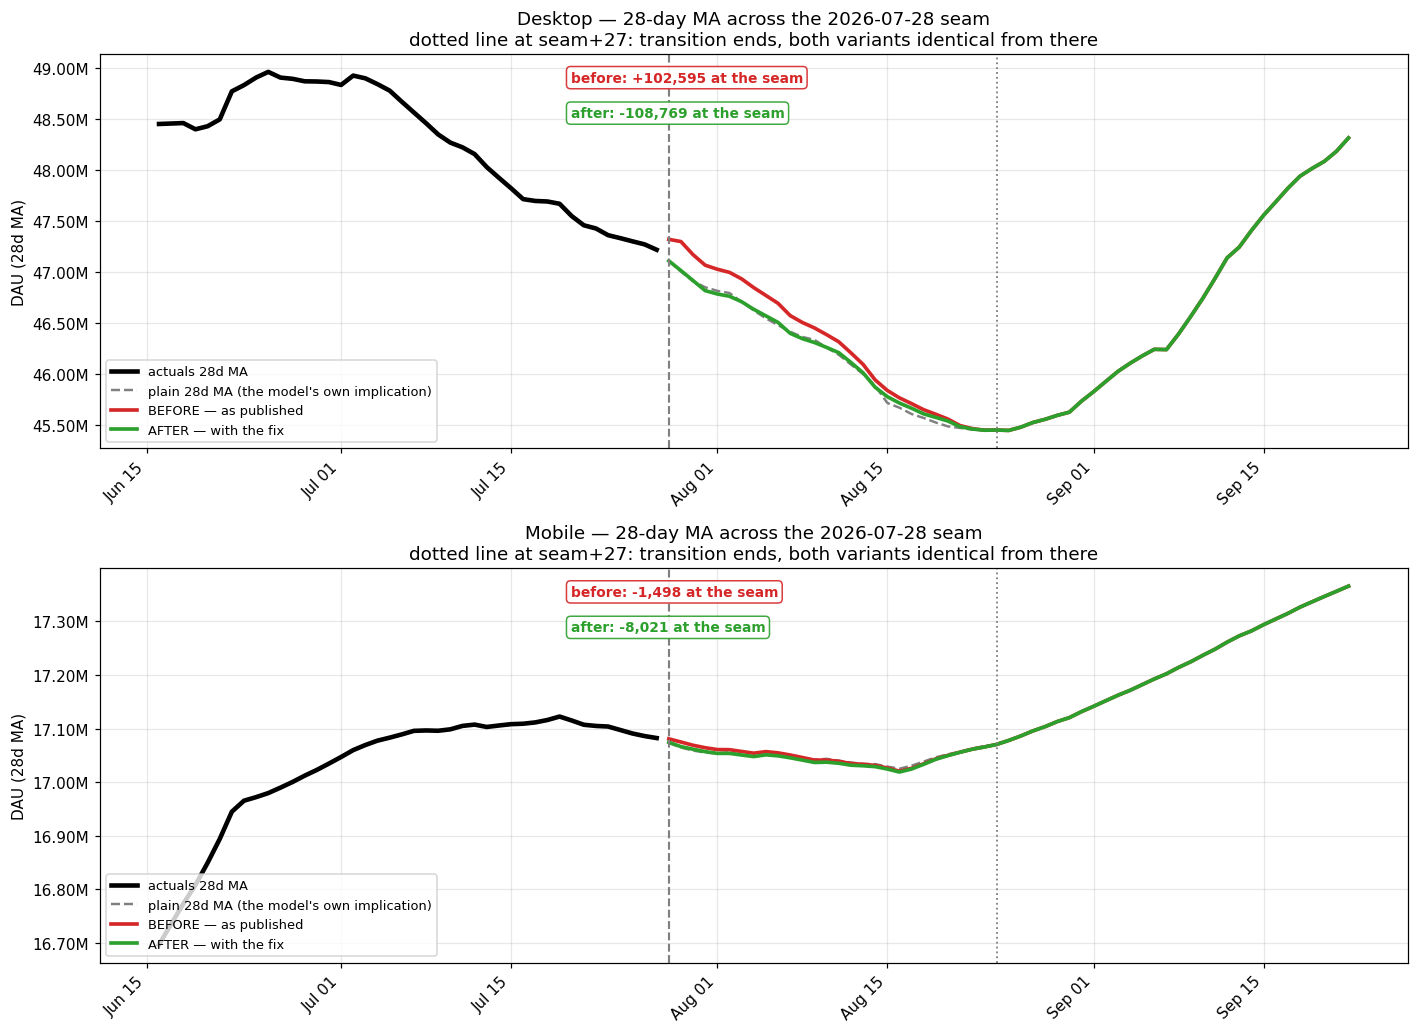

In [4]:
# [plot-ma]
# THE MAIN VIEW. Published curve vs fixed curve, seam zoomed, one row per platform. The dashed grey
# plain MA is the model's own implication — the fixed curve should sit on it at the seam, and the
# published one should visibly step away from it.
ZOOM = (SEAM - pd.Timedelta(days=42), SEAM + pd.Timedelta(days=56))

fig, axes = plt.subplots(2, 1, figsize=(13, 9.5))
for ax, (name, c) in zip(axes, curves.items()):
    view = pd.date_range(*ZOOM)
    actuals_ma = c["plain"].reindex(view).where(view < SEAM)

    ax.plot(view, actuals_ma, lw=3.0, color="black", label="actuals 28d MA", zorder=5)
    ax.plot(view, c["plain"].reindex(view).where(view >= SEAM), lw=1.6, color="grey", ls="--",
            label="plain 28d MA (the model's own implication)")
    ax.plot(view, c["before"].reindex(view).where(view >= SEAM), lw=2.4, color="tab:red",
            label="BEFORE — as published")
    ax.plot(view, c["after"].reindex(view).where(view >= SEAM), lw=2.4, color="tab:green",
            label="AFTER — with the fix")
    ax.axvline(SEAM, color="grey", ls="--", lw=1.4)
    ax.axvline(SEAM + pd.Timedelta(days=WINDOW - 1), color="grey", ls=":", lw=1.2)

    # Annotations placed in AXES coordinates, not data coordinates: mobile's steps are tiny
    # relative to its y-range, so data-relative offsets put the two labels on top of each other.
    prev = SEAM - pd.Timedelta(days=1)
    # No arrows: an arrow from an axes-fraction label down to the seam crosses the whole plot and
    # reads as a data line. The label colours already match their curves.
    for variant, colour, y_frac in [("before", "tab:red", 0.94), ("after", "tab:green", 0.85)]:
        step = c[variant].loc[SEAM] - c["plain"].loc[prev]
        ax.text(0.36, y_frac, f"{variant}: {step:+,.0f} at the seam",
                transform=ax.transAxes, color=colour, fontweight="bold", fontsize=9,
                va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colour, alpha=0.9))

    ax.set_title(f"{name.capitalize()} — 28-day MA across the 2026-07-28 seam\n"
                 f"dotted line at seam+{WINDOW - 1}: transition ends, both variants identical from there")
    ax.set_ylabel("DAU (28d MA)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.legend(loc="lower left", fontsize=8.5)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

path = f"{PLOTS_DIR}/seam_fix_before_after_ma.png"
fig.savefig(path, bbox_inches="tight")
print(f"saved: {path}")
plt.show()


saved: data-official/2026-08/plots/seam_fix_before_after_daily.png


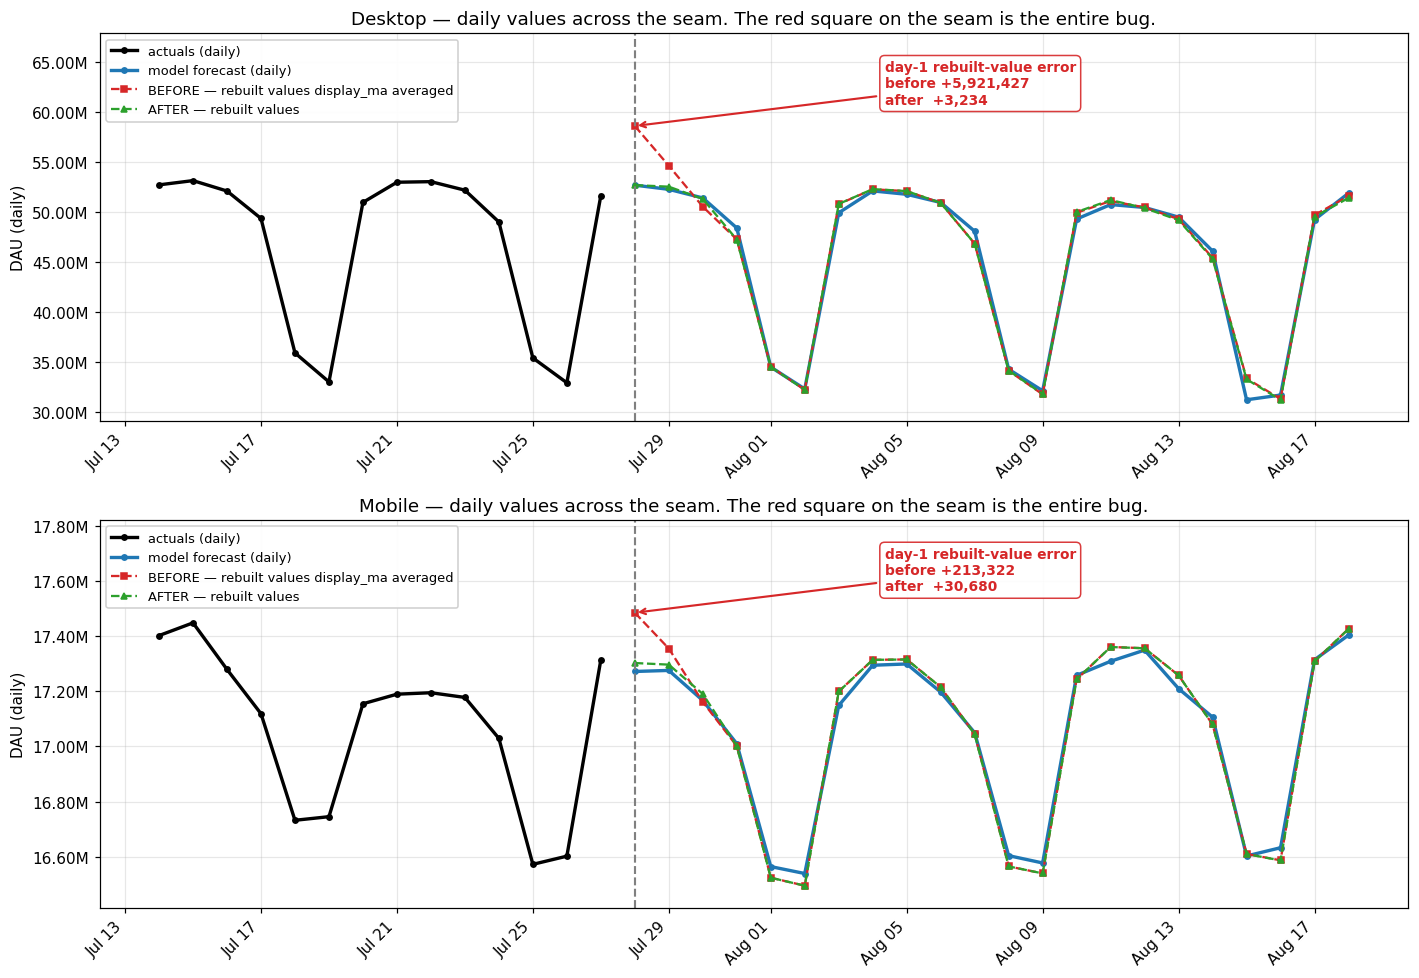


One inflated day, divided by the 28-day window, is the published step:
  desktop      +5,921,427 / 28 =    +211,480 on the MA
  mobile         +213,322 / 28 =      +7,619 on the MA


In [5]:
# [plot-daily]
# WHERE THE ARTIFACT CAME FROM. display_ma does not average the model's daily forecast during the
# transition -- it averages a REBUILT version. Before, that rebuilt day-1 value sat millions above
# the model's own. This is the spike, at daily resolution, disappearing.
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
for ax, (name, c) in zip(axes, curves.items()):
    view = pd.date_range(SEAM - pd.Timedelta(days=14), SEAM + pd.Timedelta(days=21))
    pre_daily = c["daily"].reindex(view).where(view < SEAM)

    ax.plot(view, pre_daily, lw=2.2, color="black", marker="o", ms=3.5, label="actuals (daily)")
    ax.plot(view, c["fc"].reindex(view), lw=2.2, color="tab:blue", marker="o", ms=3.5,
            label="model forecast (daily)")
    ax.plot(view, c["recon_before"].reindex(view), lw=1.5, color="tab:red", ls="--", marker="s",
            ms=4, label="BEFORE — rebuilt values display_ma averaged")
    ax.plot(view, c["recon_after"].reindex(view), lw=1.5, color="tab:green", ls="--", marker="^",
            ms=4, label="AFTER — rebuilt values")
    ax.axvline(SEAM, color="grey", ls="--", lw=1.4)

    # Headroom at the top so the callout and the legend both sit clear of the curves and the
    # title, rather than over a weekend trough or under the heading.
    visible = pd.concat([pre_daily.dropna(), c["recon_before"].reindex(view).dropna()])
    lo, hi = visible.min(), visible.max()
    span = hi - lo
    ax.set_ylim(lo - 0.08 * span, hi + 0.34 * span)

    err_before = c["recon_before"].loc[SEAM] - c["fc"].loc[SEAM]
    err_after = c["recon_after"].loc[SEAM] - c["fc"].loc[SEAM]
    ax.annotate(f"day-1 rebuilt-value error\nbefore {err_before:+,.0f}\nafter  {err_after:+,.0f}",
                xy=(SEAM, c["recon_before"].loc[SEAM]), xycoords="data",
                xytext=(0.60, 0.93), textcoords="axes fraction",
                arrowprops=dict(arrowstyle="->", color="tab:red", lw=1.4),
                color="tab:red", fontweight="bold", fontsize=9, va="top",
                bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="tab:red", alpha=0.9))

    ax.set_title(f"{name.capitalize()} — daily values across the seam. "
                 f"The red square on the seam is the entire bug.")
    ax.set_ylabel("DAU (daily)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.legend(loc="upper left", fontsize=8.5, framealpha=0.95)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

path = f"{PLOTS_DIR}/seam_fix_before_after_daily.png"
fig.savefig(path, bbox_inches="tight")
print(f"saved: {path}")
plt.show()

print("\nOne inflated day, divided by the 28-day window, is the published step:")
for name, c in curves.items():
    err = c["recon_before"].loc[SEAM] - c["fc"].loc[SEAM]
    print(f"  {name:8s} {err:>+14,.0f} / {WINDOW} = {err / WINDOW:>+11,.0f} on the MA")


<!-- [md-verdict] -->
## Sign-off checklist

| # | Check | Where |
|---|---|---|
| 1 | Dec-15 and all far-horizon values byte-identical, both platforms | `[assert-far-horizon]` — asserts, does not just print |
| 2 | Display-layer distortion (`vs_plain_step`) collapses toward 0 | `[compute]` table |
| 3 | The day-1 rebuilt-value spike is gone | `[plot-daily]` |
| 4 | The fixed curve tracks the plain 28-day MA at the seam | `[plot-ma]`, green vs dashed grey |
| 5 | June and July cannot have moved | structural — they import the untouched frozen copy |

## Your judgement call

The fixed August desktop curve leaves the actuals heading **down**, not up. That is the model's
actual view; the previous upward step was the bug. Decide whether that is what you want published.

If it isn't, the options are a model change or an explicit, documented display choice — **not** a
further adjustment to this estimator. Tuning the estimator until the picture looks right is how the
current situation arose: the old `|seam step|` acceptance criterion rewarded a small step, and a
small step is exactly what two cancelling errors produce.

## Signed off 2026-07-29 — DO NOT RE-EXECUTE

**This notebook is the proof of the choice and is frozen with its executed outputs.** Do not rerun it.

It is the only file in the live tree that imports the frozen `data-official/2026-06/export_canonical_curves.py`,
and that import is **deliberately retained**: without it there is no "before" curve, and the record of
what the fix changed would be a claim rather than a comparison. An earlier plan step called for
stripping the import on sign-off; that was **countermanded** — keeping it is the point.

Rerunning is not merely unnecessary, it is lossy. The "before" series depends on the frozen
implementation still being importable; if that ever moves, a rerun would fail or silently produce two
identical curves, destroying the evidence while looking like it worked. The stored outputs are the
artifact.

If the seam MA is changed again, write a *new* before/after notebook for that change rather than
re-executing this one.

### What was verified here

- Dec-15 and every date from seam+27 onward: **byte-identical**, both platforms, 495 dates each
- Desktop display distortion: **211,480 → 116 DAU**
- Mobile display distortion: **7,619 → 1,096 DAU**
- The day-1 rebuilt-value spike (+5,921,427 desktop) eliminated

Full record: `research/ma-seam-turbulence/LOG.md` § Fix A.
